In [9]:
import sys
sys.path.append("../")
from analysis import System as syst
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import periodogram, welch
from scipy.optimize import curve_fit as fit
def signal(t, a, b, c):
    return a * np.sin(np.pi * 1.08e5 * t + b)**2 + c
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]
def find_idx(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx
def pp(arr, d, i):
    arr.set_data(ind = i)
    d.apply("time_gate", tmin = 0, tmax = 5e-4, inplace = True)
    d.apply("detrend", mode = "linear", inplace = True)

In [10]:
piezo = syst(
    "piezo",
    ["/mnt/c/Users/Mitch/OneDrive - The University of Texas at Austin/Desktop/piezo_data/20251105/20251105/piezo_char2/iter_" + str(x) + ".tdms" for x in range(33)],
    channel="X",
    set_data=True
)

IndexError: index 3 is out of bounds for axis 0 with size 3

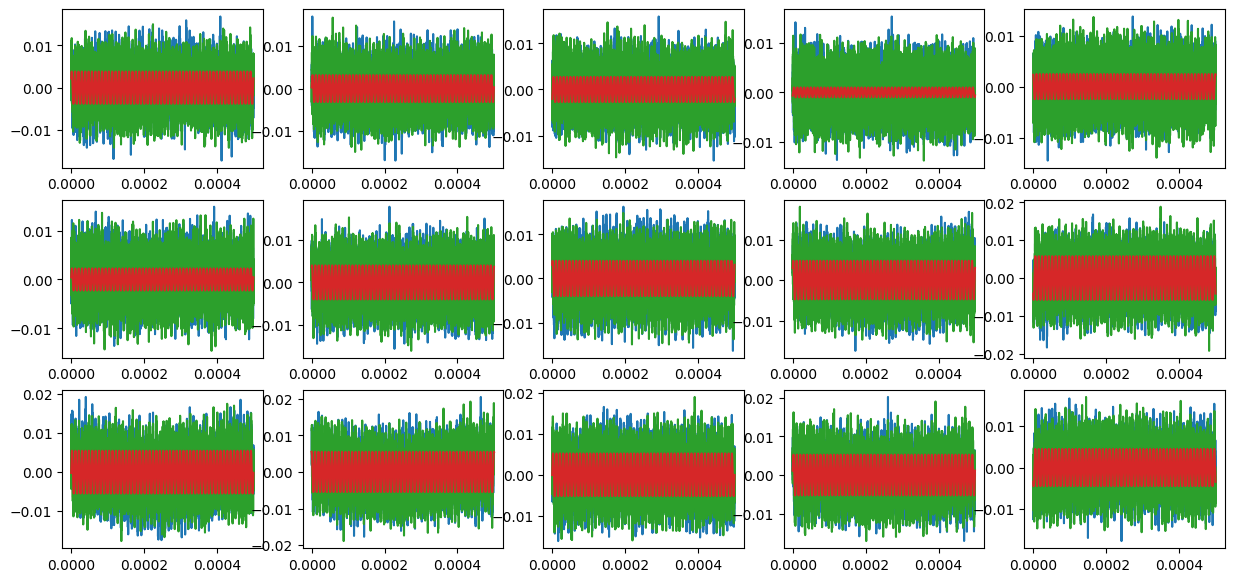

In [11]:
fig, ax = plt.subplots(3, 5, figsize = (15, 7))
calc_psd = []
data_psd = []
amplitudes = []
for i, d in enumerate(piezo.get_data()):
    sig = 0
    p = []
    a=[]
    pp(piezo, d, i)
    
    ax[int(i / 5)][i % 5].plot(d.collection[0].t, d.collection[0].x)
    sig = fit(signal, d.collection[0].t, d.collection[0].x, [0.005, 0, 0])
    a.append(sig[0][0])
    p.append(sig[0][0] ** 2 / (1.08e5 / (2 * np.pi)))
    ax[int(i / 5)][i % 5].plot(d.collection[0].t, signal(d.collection[0].t, sig[0][0], sig[0][1], sig[0][2]))

    ax[int(i / 5)][i % 5].plot(d.collection[1].t, d.collection[1].x)
    sig = fit(signal, d.collection[1].t, d.collection[1].x, [0.005, 0, 0])
    a.append(sig[0][0])
    p.append(sig[0][0] ** 2 / (1.08e5 / (2 * np.pi)))
    ax[int(i / 5)][i % 5].plot(d.collection[1].t, signal(d.collection[1].t, sig[0][0], sig[0][1], sig[0][2]))
    
    calc_psd.append(p)
    
calc_psd = np.array(calc_psd)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(3, 5, figsize = (15, 7))
for i, d in enumerate(piezo.get_data()):
    pp(piezo, d, i)

    p = []
    f, x = periodogram(d.collection[0].x, piezo.get_data()[i].r, nfft = 1e6)
    p.append(x[find_idx(f, find_nearest(f, 1.08e5))])
    ax[int(i / 5)][i % 5].plot(f, x, alpha = 0.3)
    avg = np.array(x)
    
    f, x = periodogram(d.collection[1].x, piezo.get_data()[i].r, nfft = 1e6)
    p.append(x[find_idx(f, find_nearest(f, 1.08e5))])
    ax[int(i / 5)][i % 5].plot(f, x, alpha = 0.3)
    avg = (avg + x) / 2
    
    ax[int(i / 5)][i % 5].plot(f, avg, c = "k")
    ax[int(i / 5)][i % 5].scatter(1.08e5, np.mean(calc_psd[i]), c = "r")
    ax[int(i / 5)][i % 5].set_xlim(1.03e5, 1.13e5)
    data_psd.append(p)

data_psd = np.array(data_psd)
plt.tight_layout()
plt.show()

In [12]:
piezo = syst(
    "piezo",
    ["/mnt/c/Users/Mitch/OneDrive - The University of Texas at Austin/Desktop/piezo_data/20251105/20251105/piezo_char2/iter_" + str(x) + ".tdms" for x in range(15)],
    channel="X",
    set_data=True
)

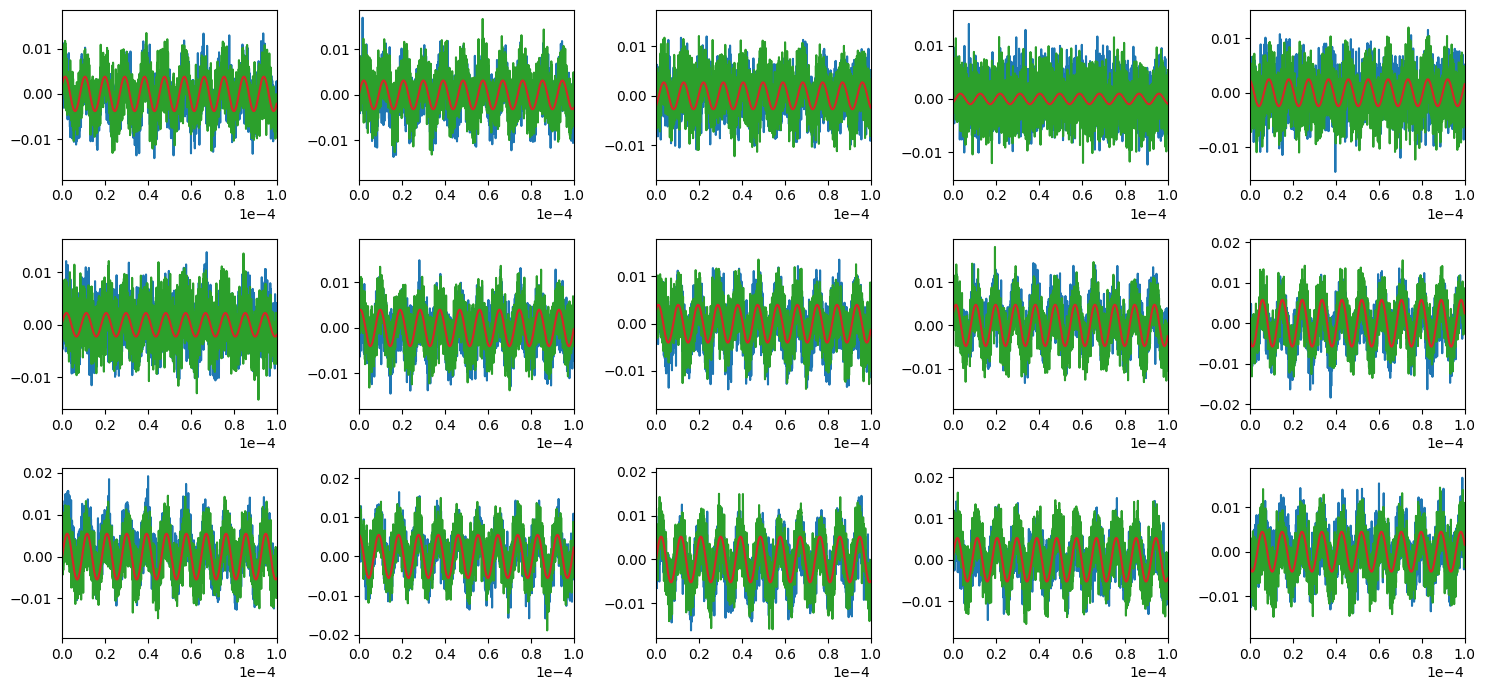

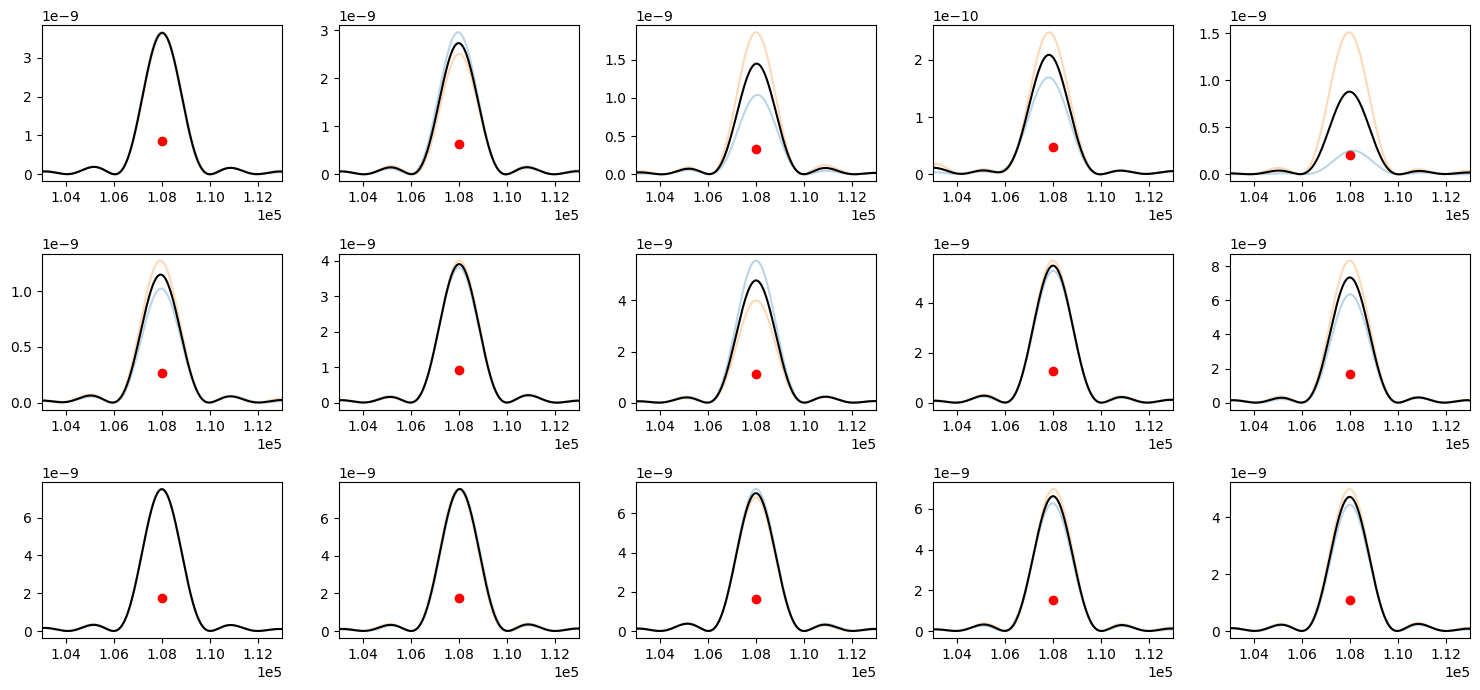

In [13]:
fig, ax = plt.subplots(3, 5, figsize = (15, 7))
calc_psd = []
data_psd = []
amps = []
 
for i, d in enumerate(piezo.get_data()):
    sig = 0
    p = []
    a = []
    pp(piezo, d, i)
    
    ax[int(i / 5)][i % 5].plot(d.collection[0].t, d.collection[0].x)
    ax[i//5][i % 5].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    sig = fit(signal, d.collection[0].t, d.collection[0].x, [0.005, 0, 0])
    a.append(np.abs(sig[0][0]))
    p.append(sig[0][0] ** 2 / (1.08e5 / (2 * np.pi)))
    ax[int(i / 5)][i % 5].plot(d.collection[0].t, signal(d.collection[0].t, sig[0][0], sig[0][1], sig[0][2]))

    ax[int(i / 5)][i % 5].plot(d.collection[1].t, d.collection[1].x)
    sig = fit(signal, d.collection[1].t, d.collection[1].x, [0.005, 0, 0])
    a.append(np.abs(sig[0][0]))
    p.append(sig[0][0] ** 2 / (1.08e5 / (2 * np.pi)))
    ax[int(i / 5)][i % 5].plot(d.collection[1].t, signal(d.collection[1].t, sig[0][0], sig[0][1], sig[0][2]))
    
    ax[int(i / 5)][i % 5].set_xlim(0, 1e-4)
    calc_psd.append(p)
    amps.append(a)
    
calc_psd = np.array(calc_psd)
amps = np.array(amps)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(3, 5, figsize = (15, 7))
for i, d in enumerate(piezo.get_data()):
    pp(piezo, d, i)

    p = []
    f, x = periodogram(d.collection[0].x, piezo.get_data()[i].r, nfft = 1e6)
    p.append(x[find_idx(f, find_nearest(f, 1.08e5))])
    ax[int(i / 5)][i % 5].plot(f, x, alpha = 0.3)
    avg = np.array(x)
    
    f, x = periodogram(d.collection[1].x, piezo.get_data()[i].r, nfft = 1e6)
    p.append(x[find_idx(f, find_nearest(f, 1.08e5))])
    ax[int(i / 5)][i % 5].plot(f, x, alpha = 0.3)
    avg = (avg + x) / 2
    
    ax[int(i / 5)][i % 5].plot(f, avg, c = "k")
    ax[i//5][i % 5].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    ax[int(i / 5)][i % 5].scatter(1.08e5, np.mean(calc_psd[i]), c = "r")
    ax[int(i / 5)][i % 5].set_xlim(1.03e5, 1.13e5)
    data_psd.append(p)

data_psd = np.array(data_psd)
plt.tight_layout()
plt.show()

In [16]:
print(np.mean(np.mean(amps, axis = 1)))

0.003895313154380176


In [15]:
# rails are just half wavelength, the average amplitudes a value a times sine squared, and then 1.8 is the change in max to min voltage
((6.64e-6 - 6.08e-6)) * 0.00763201 / 1.8

2.37440311111111e-09